# AIME quartile delta analysis

This notebook compares each dataset index's eval solve rate against its `step == 1` solve-rate baseline.

It does not assume dataset indices are pre-grouped by quartile. Instead, it infers quartile labels from the eval results at `step == 1`, using the step-1 `solve_rate` ranking for each `dataset_index`.

Expected CSV columns:
- `dataset_index`
- `id`
- `name`
- `solve_rate`

If your CSV does not have a `step` column, the notebook extracts it from `name` when it contains `step_XXXX`.


In [27]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

gray_coolwarm = LinearSegmentedColormap.from_list(
    "gray_coolwarm",
    [
        (0.0, "#3b4cc0"),
        (0.5, "#bdbdbd"),
        (1.0, "#b40426"),
    ],
)

EVAL_CSV_PATH = Path("../notebooks/wandb_export_ds15b.csv")
QUARTILE_REFERENCE_STEP = 1
NUM_QUARTILES = 4


In [7]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [re.sub(r"[^0-9a-zA-Z]+", "_", col.strip().lower()).strip("_") for col in df.columns]
    return df


def parse_step_from_name(name: str) -> int:
    match = re.search(r"step_(\d+)", str(name))
    if match is None:
        raise ValueError(f"Could not parse a step from {name!r}")
    return int(match.group(1))


def load_eval_csv(path: Path) -> pd.DataFrame:
    df = normalize_columns(pd.read_csv(path))

    if "dataset_index" not in df.columns:
        if "index" in df.columns:
            df = df.rename(columns={"index": "dataset_index"})
        else:
            raise ValueError("The eval CSV needs a dataset_index column.")

    if "solve_rate" not in df.columns:
        if "pass_rate" in df.columns:
            df = df.rename(columns={"pass_rate": "solve_rate"})
        else:
            raise ValueError("The eval CSV needs a solve_rate column.")

    if "step" not in df.columns:
        if "name" not in df.columns:
            raise ValueError("The eval CSV needs either a step column or a name column containing step_XXXX.")
        df["step"] = df["name"].map(parse_step_from_name)

    df["dataset_index"] = pd.to_numeric(df["dataset_index"], errors="raise").astype(int)
    df["solve_rate"] = pd.to_numeric(df["solve_rate"], errors="raise")
    df["step"] = pd.to_numeric(df["step"], errors="raise").astype(int)

    return df


def build_reference_from_step(eval_df: pd.DataFrame, reference_step: int, num_quartiles: int = 4) -> pd.DataFrame:
    step_df = eval_df.loc[eval_df["step"] == reference_step].copy()
    if step_df.empty:
        available_steps = sorted(eval_df["step"].dropna().unique().tolist())
        raise ValueError(
            f"No eval rows found for reference step {reference_step}. Available steps: {available_steps[:20]}"
        )

    aggregations = {"solve_rate": "mean"}
    optional_columns = ["dataset", "id", "name"]
    for column in optional_columns:
        if column in step_df.columns:
            aggregations[column] = "first"

    step_df = step_df.groupby("dataset_index", as_index=False).agg(aggregations)

    ranked = step_df["solve_rate"].rank(method="first")
    step_df["quartile"] = pd.qcut(ranked, q=num_quartiles, labels=False).astype(int)
    step_df = step_df.rename(columns={"solve_rate": "initial_pass_at_1"})
    return step_df


In [12]:
eval_df = load_eval_csv(EVAL_CSV_PATH)

In [13]:
eval_df = eval_df[eval_df["dataset_index"].between(0, 29)].copy()

In [14]:
reference_df = build_reference_from_step(
    eval_df,
    reference_step=QUARTILE_REFERENCE_STEP,
    num_quartiles=NUM_QUARTILES,
)

merged = eval_df.merge(
    reference_df,
    on="dataset_index",
    how="left",
    validate="many_to_one",
    suffixes=("", "_reference"),
)
merged["delta_vs_initial_pass_at_1"] = merged["solve_rate"] - merged["initial_pass_at_1"]
merged = merged.sort_values(["quartile", "initial_pass_at_1", "dataset_index", "step"]).reset_index(drop=True)

quartile_counts = reference_df.groupby("quartile").size().rename("count").reset_index()
display(quartile_counts)
display(merged.head())
display(merged[["step", "delta_vs_initial_pass_at_1"]].groupby("step", as_index=False).mean())


,quartile,count
0,0,8
1,1,7
2,2,7
3,3,8


,dataset_index,id,name,solve_rate,step,initial_pass_at_1,id_reference,name_reference,quartile,delta_vs_initial_pass_at_1
0,6,es696ka6,deepseek1.5b_aime_brumo_eval_20260327_144846_s...,0.0,1,0.0,es696ka6,deepseek1.5b_aime_brumo_eval_20260327_144846_s...,0,0.0
1,6,yxubyh99,deepseek1.5b_aime_brumo_eval_20260327_155919_s...,0.0,200,0.0,es696ka6,deepseek1.5b_aime_brumo_eval_20260327_144846_s...,0,0.0
2,6,t1yi1t51,deepseek1.5b_aime_brumo_eval_20260327_155919_s...,0.0,400,0.0,es696ka6,deepseek1.5b_aime_brumo_eval_20260327_144846_s...,0,0.0
3,6,xmrcnvef,deepseek1.5b_aime_brumo_eval_20260327_155919_s...,0.0,600,0.0,es696ka6,deepseek1.5b_aime_brumo_eval_20260327_144846_s...,0,0.0
4,6,abrjziur,deepseek1.5b_aime_brumo_eval_20260327_155919_s...,0.0,800,0.0,es696ka6,deepseek1.5b_aime_brumo_eval_20260327_144846_s...,0,0.0


,step,delta_vs_initial_pass_at_1
0,1,0.000000
1,200,0.025000
2,400,0.060417
3,600,0.076042
4,800,0.078125
5,1000,0.070833
6,1200,0.087500
7,1400,0.086458
8,1600,0.095833
9,1800,0.096875


## Pass@1 and delta over steps

The first two plots show the mean solve rate and mean solve rate by quartile. The next two plots show the corresponding delta relative to the `step == 1` baseline.


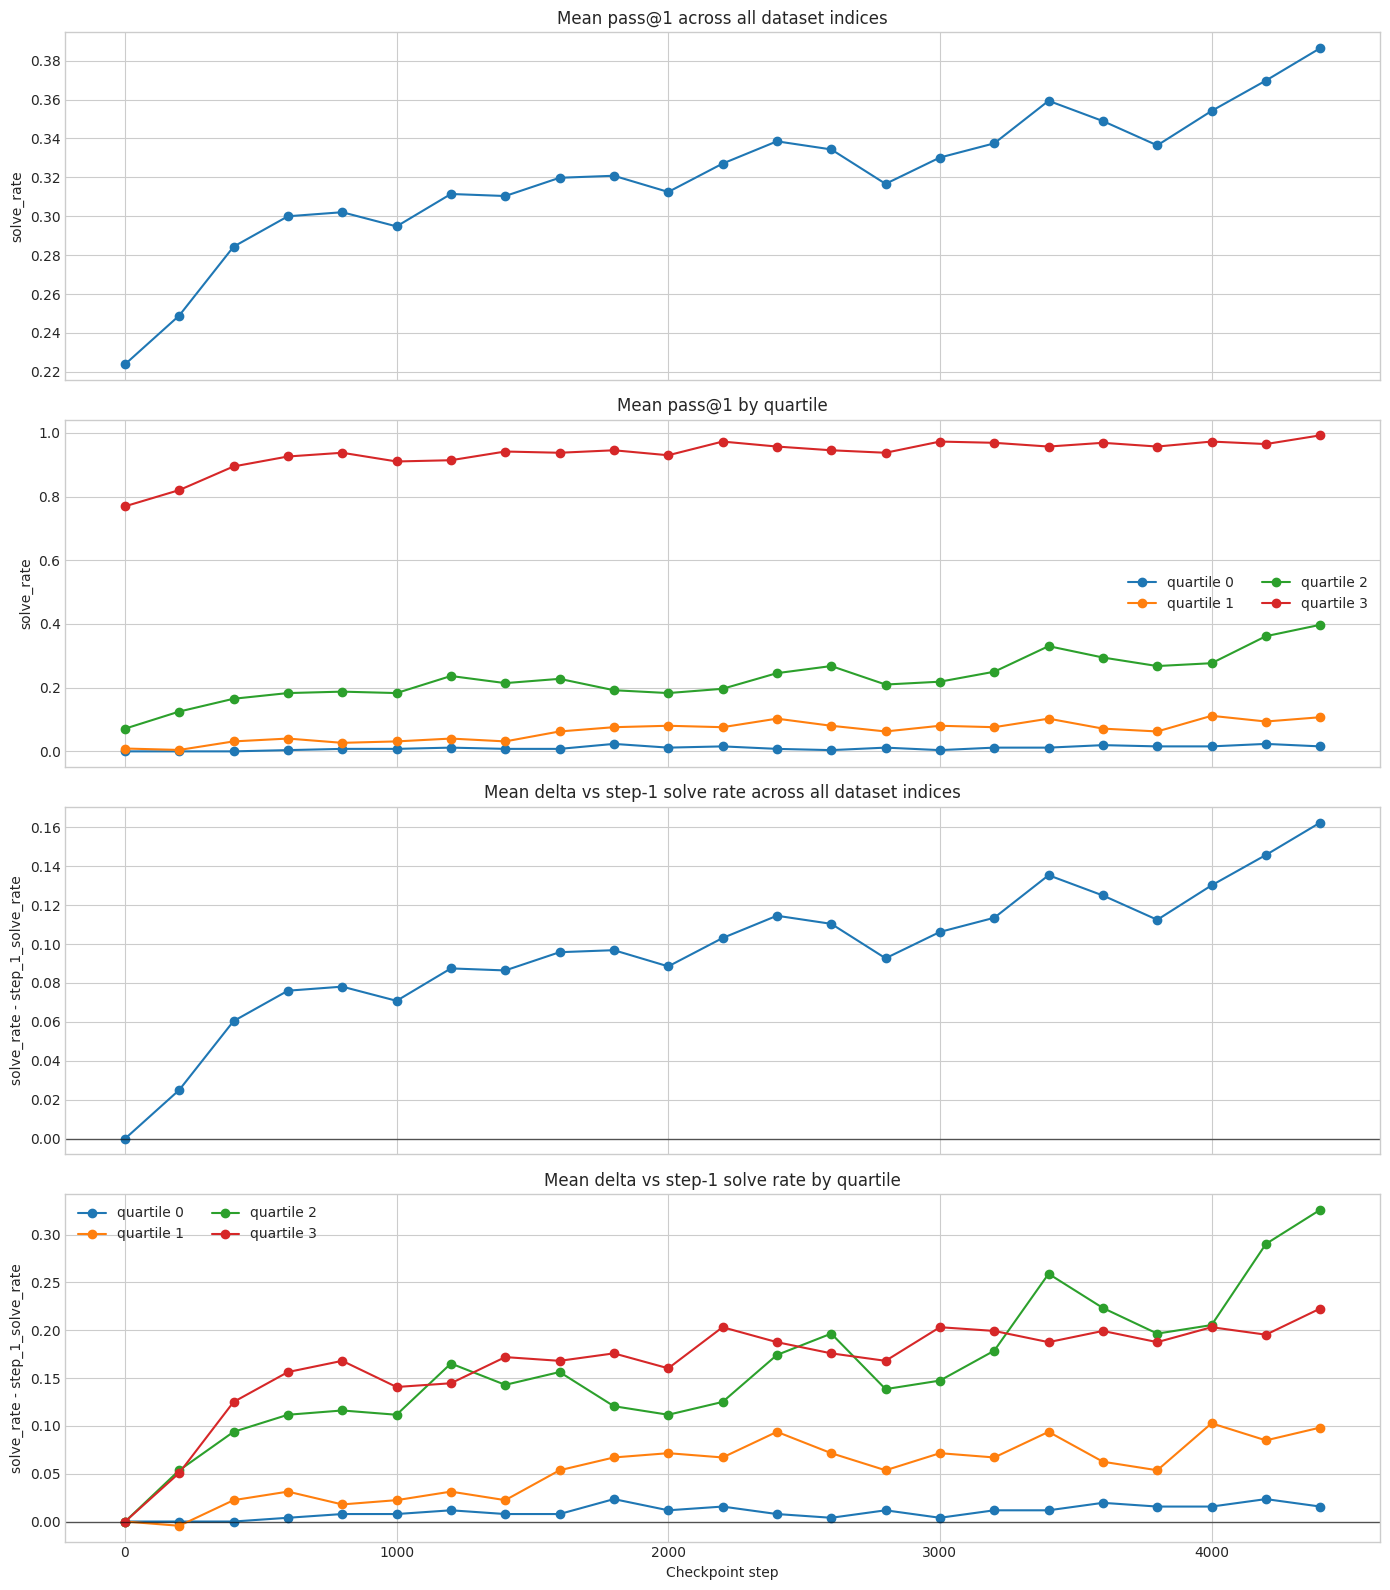

In [15]:
step_pass_at_1_summary = merged.groupby("step", as_index=False)["solve_rate"].mean()
quartile_pass_at_1_summary = (
    merged.groupby(["step", "quartile"], as_index=False)["solve_rate"].mean().sort_values(["quartile", "step"])
)
step_summary = merged.groupby("step", as_index=False)["delta_vs_initial_pass_at_1"].mean()
quartile_summary = (
    merged.groupby(["step", "quartile"], as_index=False)["delta_vs_initial_pass_at_1"].mean().sort_values(["quartile", "step"])
)

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

axes[0].plot(step_pass_at_1_summary["step"], step_pass_at_1_summary["solve_rate"], marker="o")
axes[0].set_title("Mean pass@1 across all dataset indices")
axes[0].set_ylabel("solve_rate")

for quartile, subset in quartile_pass_at_1_summary.groupby("quartile"):
    axes[1].plot(subset["step"], subset["solve_rate"], marker="o", label=f"quartile {int(quartile)}")

axes[1].set_title("Mean pass@1 by quartile")
axes[1].set_ylabel("solve_rate")
axes[1].legend(ncol=2)

axes[2].plot(step_summary["step"], step_summary["delta_vs_initial_pass_at_1"], marker="o")
axes[2].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[2].set_title("Mean delta vs step-1 solve rate across all dataset indices")
axes[2].set_ylabel("solve_rate - step_1_solve_rate")

for quartile, subset in quartile_summary.groupby("quartile"):
    axes[3].plot(subset["step"], subset["delta_vs_initial_pass_at_1"], marker="o", label=f"quartile {int(quartile)}")

axes[3].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[3].set_title("Mean delta vs step-1 solve rate by quartile")
axes[3].set_xlabel("Checkpoint step")
axes[3].set_ylabel("solve_rate - step_1_solve_rate")
axes[3].legend(ncol=2)

plt.tight_layout()
plt.show()


## Heatmaps by dataset index

The first heatmap shows the raw solve rate at each checkpoint for every dataset index. The second shows the delta relative to the `step == 1` baseline.

Rows are ordered by inferred quartile first, then by the `step == 1` solve rate within each quartile.


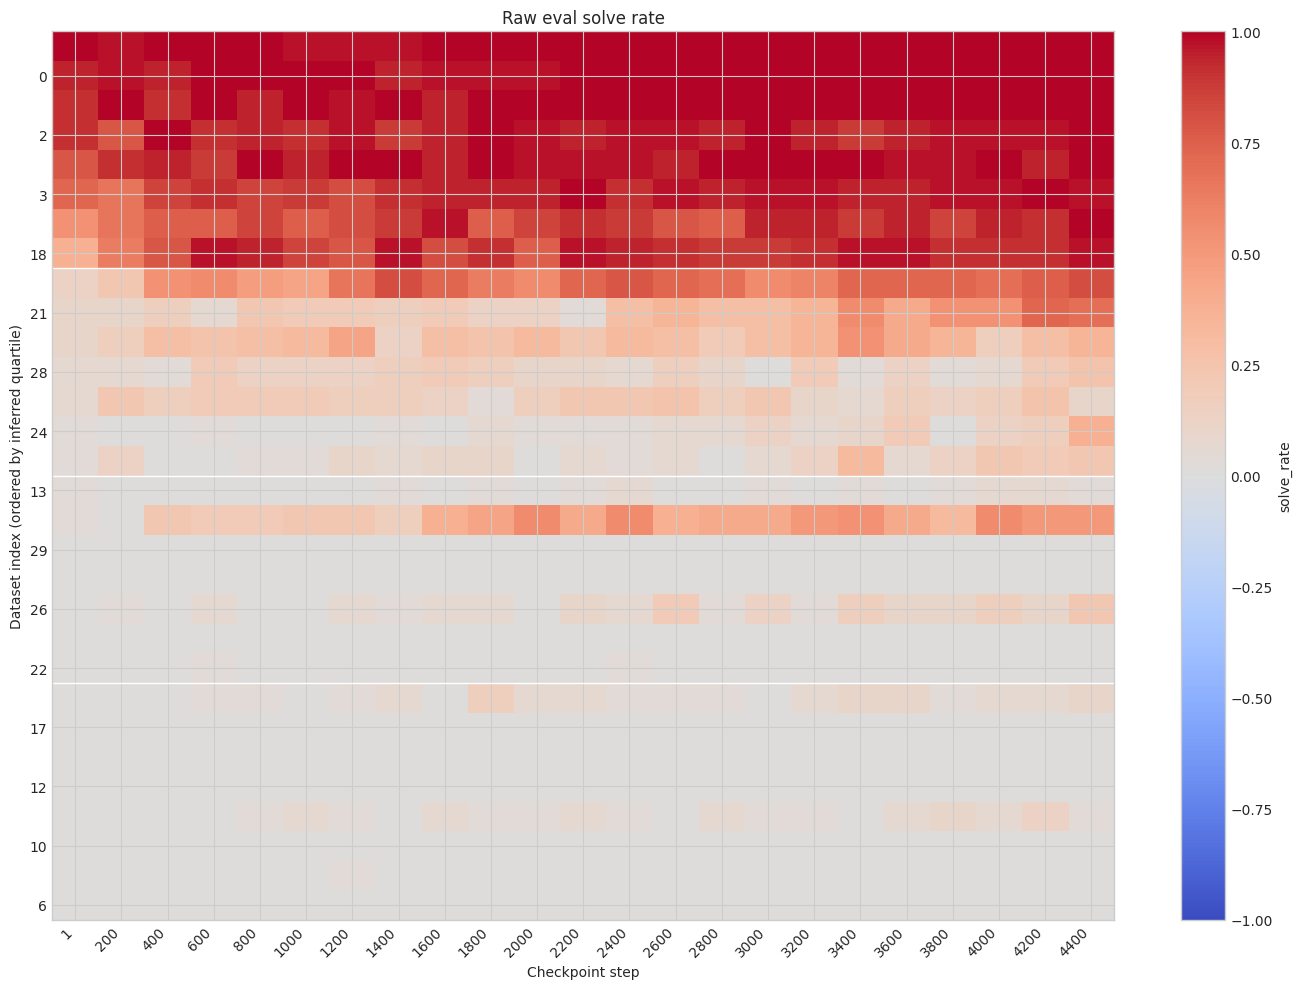

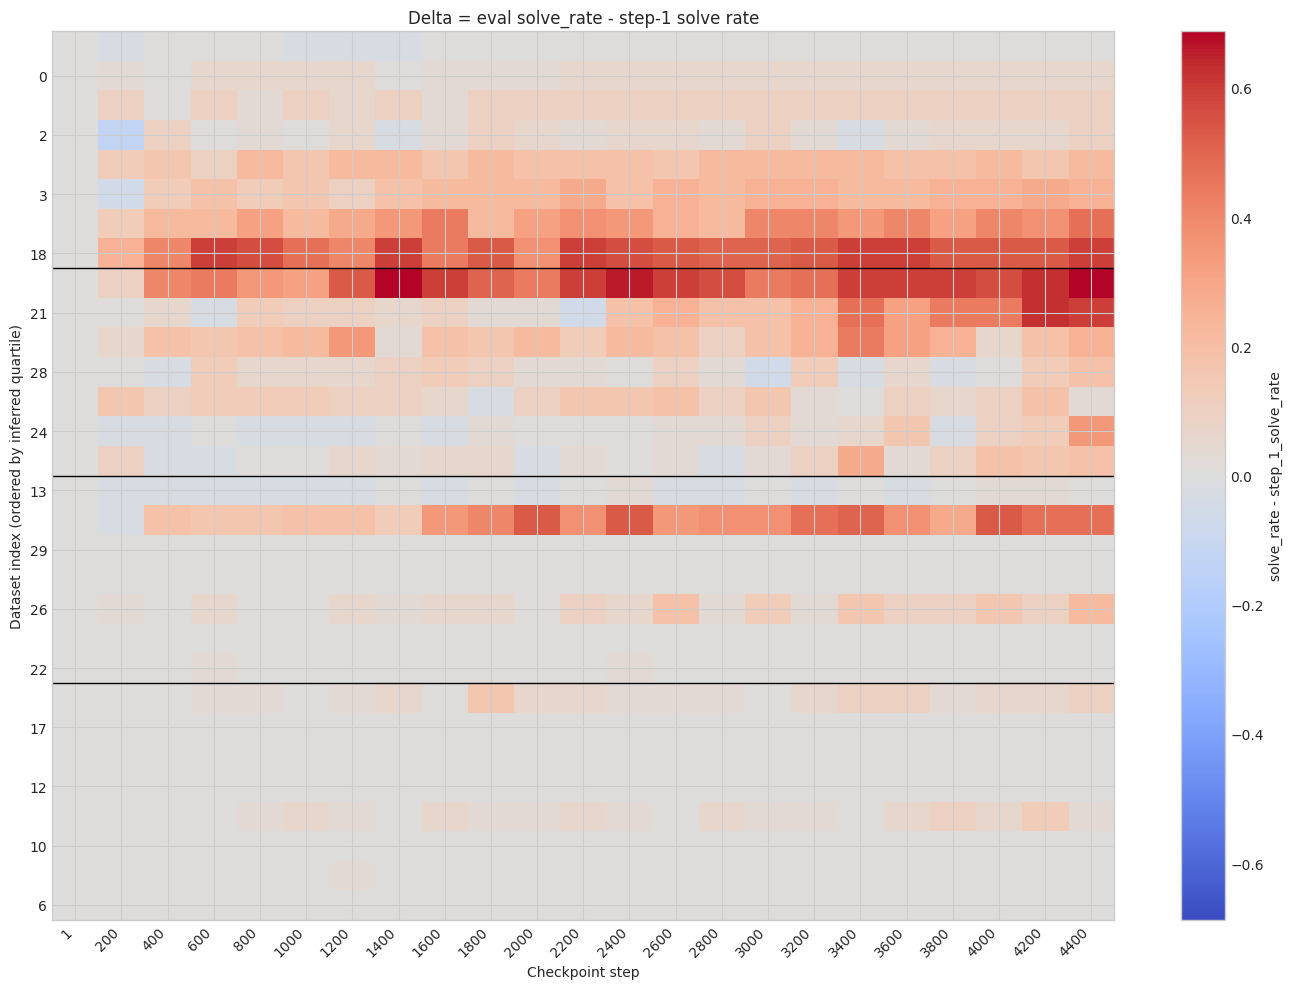

In [30]:
row_order = reference_df.sort_values(["quartile", "initial_pass_at_1", "dataset_index"])["dataset_index"].tolist()
quartile_sizes = reference_df.sort_values(["quartile", "initial_pass_at_1", "dataset_index"]).groupby("quartile").size().tolist()

raw_heatmap = (
    merged.pivot_table(
        index="dataset_index",
        columns="step",
        values="solve_rate",
        aggfunc="mean",
    )
    .reindex(row_order)
    .sort_index(axis=1)
)

raw_heatmap_values = raw_heatmap.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(14, 10))
image = ax.imshow(
    raw_heatmap_values,
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)

ax.set_title("Raw eval solve rate")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("Dataset index (ordered by inferred quartile)")
ax.set_xticks(np.arange(len(raw_heatmap.columns)))
ax.set_xticklabels(raw_heatmap.columns.tolist(), rotation=45, ha="right")

tick_positions = np.arange(0, len(raw_heatmap.index), max(1, len(raw_heatmap.index) // 12))
ax.set_yticks(tick_positions)
ax.set_yticklabels([int(raw_heatmap.index[i]) for i in tick_positions])

boundary = 0
for size in quartile_sizes[:-1]:
    boundary += size
    ax.axhline(boundary - 0.5, color="white", linewidth=1)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("solve_rate")
plt.tight_layout()
plt.show()

delta_heatmap = (
    merged.pivot_table(
        index="dataset_index",
        columns="step",
        values="delta_vs_initial_pass_at_1",
        aggfunc="mean",
    )
    .reindex(row_order)
    .sort_index(axis=1)
)

delta_heatmap_values = delta_heatmap.to_numpy(dtype=float)
max_abs = float(np.nanmax(np.abs(delta_heatmap_values))) if np.isfinite(delta_heatmap_values).any() else 1.0
max_abs = max(max_abs, 1e-9)

fig, ax = plt.subplots(figsize=(14, 10))
image = ax.imshow(
    delta_heatmap_values,
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs,
)

ax.set_title("Delta = eval solve_rate - step-1 solve rate")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("Dataset index (ordered by inferred quartile)")
ax.set_xticks(np.arange(len(delta_heatmap.columns)))
ax.set_xticklabels(delta_heatmap.columns.tolist(), rotation=45, ha="right")

tick_positions = np.arange(0, len(delta_heatmap.index), max(1, len(delta_heatmap.index) // 12))
ax.set_yticks(tick_positions)
ax.set_yticklabels([int(delta_heatmap.index[i]) for i in tick_positions])

boundary = 0
for size in quartile_sizes[:-1]:
    boundary += size
    ax.axhline(boundary - 0.5, color="black", linewidth=1)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("solve_rate - step_1_solve_rate")
plt.tight_layout()
plt.show()


## Inspect a single dataset index

Set `DATASET_INDEX_TO_PLOT` to any dataset index you want to inspect in detail.


In [ ]:
DATASET_INDEX_TO_PLOT = int(row_order[0]) if row_order else 0

one_index = merged[merged["dataset_index"] == DATASET_INDEX_TO_PLOT].sort_values("step").copy()
display(
    one_index[
        [
            "step",
            "dataset_index",
            "quartile",
            "initial_pass_at_1",
            "solve_rate",
            "delta_vs_initial_pass_at_1",
            "name",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(one_index["step"], one_index["delta_vs_initial_pass_at_1"], marker="o")
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.set_title(f"Dataset index {DATASET_INDEX_TO_PLOT}: delta vs step-1 solve rate")
ax.set_xlabel("Checkpoint step")
ax.set_ylabel("solve_rate - step_1_solve_rate")
plt.tight_layout()
plt.show()
